### Experimental Setup

In [1]:
FEATURE_SELECTION_METHOD = "ANOVA"
DEEP_LEARNING_CATEGORY = "Attention"
MODEL_ARCHITECTURE = "BERT"
DATASET_NAME = "Combined"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu 

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Import Necessary Packages

In [2]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import sys
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd
import scipy

# ============================================================
# Visualization
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
import sklearn
from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    LSTM,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# ============================================================
# Transformers
# ============================================================
import transformers
from transformers import (
    BertTokenizer,
    GPT2Tokenizer,
    TFBertModel,
    TFGPT2Model,
)

# ============================================================
# AutoML and Model Persistence
# ============================================================
from flaml import AutoML
import joblib

### Version Checking

In [3]:
print("=" * 60)
print("Python Version")
print("=" * 60)
print(sys.version)

print("\n" + "=" * 60)
print("Core Library Versions")
print("=" * 60)
print(f"NumPy            : {np.__version__}")
print(f"Pandas           : {pd.__version__}")
print(f"Matplotlib       : {matplotlib.__version__}")
print(f"Seaborn          : {sns.__version__}")
print(f"SciPy            : {scipy.__version__}")
print(f"Scikit-learn     : {sklearn.__version__}")
print(f"TensorFlow       : {tf.__version__}")
print(f"Transformers     : {transformers.__version__}")
print(f"Joblib           : {joblib.__version__}")

print("\n" + "=" * 60)
print("Keras Version")
print("=" * 60)
print(f"Keras (tf.keras) : {tf.keras.__version__}")

print("\n" + "=" * 60)
print("CUDA / GPU Info")
print("=" * 60)
print(f"Built with CUDA  : {tf.test.is_built_with_cuda()}")
print(f"GPU Available    : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"GPUs             : {tf.config.list_physical_devices('GPU')}")

Python Version
3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]

Core Library Versions
NumPy            : 1.23.5
Pandas           : 1.5.3
Matplotlib       : 3.7.1
Seaborn          : 0.12.2
SciPy            : 1.9.3
Scikit-learn     : 1.2.2
TensorFlow       : 2.11.0
Transformers     : 4.38.2
Joblib           : 1.3.2

Keras Version
Keras (tf.keras) : 2.11.0

CUDA / GPU Info
Built with CUDA  : True
GPU Available    : True
GPUs             : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### GPU Checking

In [4]:
# ============================================================
# GPU Status and Resource Monitoring
# ============================================================

# Display NVIDIA GPU information including driver version,
# CUDA version, memory usage, and active processes

!nvidia-smi

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Fri Mar 27 19:36:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:01:00.0  On |                  Off |
| 30%   45C    P8             14W /  300W |   47290MiB /  49140MiB |      7%      Default |
|           

### GPU Status Checking

In [5]:
# ============================================================
# Detailed System and GPU Diagnostics
# ============================================================

print("=" * 60)
print("TensorFlow Environment Diagnostics")
print("=" * 60)

print(f"Conda Prefix        : {os.environ.get('CONDA_PREFIX')}")
print(f"LD_LIBRARY_PATH     : {os.environ.get('LD_LIBRARY_PATH')}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"Built with CUDA     : {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs      : {len(gpus)}")

for idx, gpu in enumerate(gpus):
    print(f"GPU {idx}            : {gpu}")

print("=" * 60)

TensorFlow Environment Diagnostics
Conda Prefix        : /home/n11894571/miniconda3/envs/tf211gpu
LD_LIBRARY_PATH     : /home/n11894571/miniconda3/envs/tf211gpu/lib:
TensorFlow Version  : 2.11.0
Built with CUDA     : True
Number of GPUs      : 1
GPU 0            : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Allocate as Much GPU Memory as Needed

In [6]:
# ============================================================
# Advanced GPU Configuration and Diagnostics
# ============================================================

gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GPU Configuration")
print("=" * 60)

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")
    
    try:
        for idx, gpu in enumerate(gpus):
            # Disable memory growth (allocate full GPU memory)
            tf.config.experimental.set_memory_growth(gpu, False)
            print(f"GPU {idx}: Memory growth disabled (full allocation mode)")
    
    except RuntimeError as e:
        print(f"RuntimeError: {e}")
else:
    print("No GPU detected. Using CPU.")

print("=" * 60)

GPU Configuration
Number of GPUs detected: 1
GPU 0: Memory growth disabled (full allocation mode)


### Load QUT-DV25 Dataset

In [7]:
# ============================================================
# Data Loading and Initial Inspection
# ============================================================

# Define the dataset file path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,IO_Operations,File_Operations,Network_Operations,Time_Operations,Security_Operations,Process_Operations,Read_Processes,Write_Processes,Read_Data_Transfer,...,Pattern_2,Pattern_3,Pattern_4,Pattern_5,Pattern_6,Pattern_7,Pattern_8,Pattern_9,Pattern_10,Level
0,10Cent10-999.0.4.tar.gz,ioctl,NaN,"getrandom, uname",NaN,NaN,getpid,"opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...",...,fstat -> ioctl -> lseek,openat -> fstat -> ioctl,newfstatat -> newfstatat -> openat,newfstatat -> openat -> fstat,newfstatat -> newfstatat -> newfstatat -> no-e...,fstat -> ioctl -> lseek -> no-error -> no-fd,openat -> fstat -> ioctl -> no-error -> no-fd,ioctl -> lseek -> lseek -> error=ENOTTY -> no-fd,read -> read -> close -> no-error -> no-fd,1
1,10Cent11-999.0.4.tar.gz,"ioctl, poll",NaN,uname,NaN,NaN,"wait4, getpid","opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...",...,read -> read -> read,newfstatat -> openat -> fstat,ioctl -> ioctl -> ioctl,newfstatat -> newfstatat -> openat,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,ioctl -> ioctl -> ioctl -> no-error -> no-fd,fcntl -> fstat -> fcntl -> no-error -> no-fd,1
2,11Cent-999.0.0.tar.gz,"ioctl, poll",pipe2,"getrandom, uname",NaN,NaN,"vfork, wait4, getpid","opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...",...,newfstatat -> newfstatat -> openat,read -> read -> read,newfstatat -> openat -> fstat,fstat -> ioctl -> lseek,newfstatat -> newfstatat -> newfstatat -> no-e...,newfstatat -> newfstatat -> openat -> no-error...,read -> read -> read -> no-error -> no-fd,openat -> fstat -> ioctl -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,1
3,11Cent-999.0.1.tar.gz,"ioctl, poll",NaN,uname,NaN,NaN,getpid,"opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...",...,read -> read -> read,newfstatat -> openat -> fstat,openat -> fstat -> fcntl,fstat -> fcntl -> fstat,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,openat -> fstat -> fcntl -> no-error -> no-fd,fstat -> fcntl -> fstat -> no-error -> no-fd,1
4,11Cent-999.0.2.tar.gz,"poll, ioctl",NaN,uname,NaN,NaN,getpid,"opensnoop-bpfcc, filetop-bpfcc, tcpstates-bpfc...","opensnoop-bpfcc, strace, StreamTrans, Classif~...","opensnoop-bpfcc, filetop-bpfcc, pip, gnome-sys...",...,read -> read -> read,newfstatat -> openat -> fstat,read -> poll -> read,poll -> read -> read,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,read -> poll -> read -> error=EAGAIN -> no-fd,newfstatat -> newfstatat -> openat -> no-error...,1


### Clear Backend Session

In [8]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Selected Features

In [10]:
selected_features =['Root_DIR_Access', 'Home_DIR_Access', 'User_DIR_Access', 'Other_DIR_Access', 'IO_Operations', 'File_Operations', 'Network_Operations', 'Read_Processes', 'Write_Processes', 'Write_Data_Transfer', 'File_Access_Processes', 'Direct_Dependencies_List']

### Data Preprocessing

In [11]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Dataset Summary
# ============================================================

print(f"Training set shape     : {X_train.shape}")
print(f"Validation set shape   : {X_val.shape}")
print(f"Test set shape         : {X_test.shape}")

Training set shape     : (9989, 12)
Validation set shape   : (2141, 12)
Test set shape         : (2141, 12)


### Setup OUTPUT_DIR

In [12]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR

'Evaluation_Outputs_Combined_ANOVA_Attention_BERT'

### Model

In [13]:
# ============================================================
# Define model saving configuration
# ============================================================

SAVE_DIR = OUTPUT_DIR
MODEL_NAME = os.path.join(SAVE_DIR, OUTPUT_DIR + ".h5")

# ==========================
# Convert each row into a single text string
# ==========================
def row_to_text(df):
    texts = []
    for _, row in df.iterrows():
        text = " ".join([f"{col}:{row[col]}" for col in df.columns])
        texts.append(text)
    return texts

train_texts = row_to_text(X_train)
val_texts   = row_to_text(X_val)
test_texts  = row_to_text(X_test)

# ==========================
# Load TensorFlow-compatible BERT tokenizer
# ==========================
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

max_len = 128

train_enc = tokenizer(train_texts, padding=True, truncation=True, max_length=max_len, return_tensors="tf")
val_enc   = tokenizer(val_texts, padding=True, truncation=True, max_length=max_len, return_tensors="tf")
test_enc  = tokenizer(test_texts, padding=True, truncation=True, max_length=max_len, return_tensors="tf")


# ==========================
# Labels
# ==========================
y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)


# ==========================
# Callbacks
# ==========================
checkpoint_cb = ModelCheckpoint(
    filepath=MODEL_NAME,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=200,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor="val_accuracy",
    patience=200,
    restore_best_weights=True
)


# ==========================
# Load TensorFlow BERT
# ==========================
bert = TFBertModel.from_pretrained("bert-base-uncased", from_pt=False)

# ==========================
# Build TensorFlow classification model
# ==========================
input_ids = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")

bert_outputs = bert(input_ids, attention_mask=attention_mask)
cls_token = bert_outputs.last_hidden_state[:, 0, :]  # CLS token

x = tf.keras.layers.Dense(128, activation="relu")(cls_token)
x = tf.keras.layers.Dropout(0.3)(x)

output_layer = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output_layer)


# ==========================
# Compile model
# ==========================
model.compile(
    tf.keras.optimizers.legacy.Adam(learning_rate=2e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 128)]        0           []                               
                                                                                                  
 attention_mask (InputLayer)    [(None, 128)]        0           []                               
                                                                                                  
 tf_bert_model (TFBertModel)    TFBaseModelOutputWi  109482240   ['input_ids[0][0]',              
                                thPoolingAndCrossAt               'attention_mask[0][0]']         
                                tentions(last_hidde                                               
                                n_state=(None, 128,                                           

### Compime the Model

In [14]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(
    {"input_ids": train_enc["input_ids"], "attention_mask": train_enc["attention_mask"]},
    y_train,
    validation_data=(
        {"input_ids": val_enc["input_ids"], "attention_mask": val_enc["attention_mask"]},
        y_val
    ),
    epochs=200,
    batch_size=16,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb]
)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200
625/625 [==============================] - ETA: 0s - loss: 0.1864 - accuracy: 0.9137
Epoch 1: val_accuracy improved from -inf to 0.96030, saving model to Evaluation_Outputs_Combined_ANOVA_Attention_BERT/Evaluation_Outputs_Combined_ANOVA_Attention_BERT.h5
625/625 [==============================] - 96s 139ms/step - loss: 0.1864 - accuracy: 0.9137 - val_loss: 0.0970 - val_accuracy: 0.9603 - lr: 2.0000e-05
Epoch 2/200
625/625 [==============================] - ETA: 0s - loss: 0.0965 - accuracy: 0.9632
Epoch 2: val_accuracy did not improve from 0.96030
625/625 [==============================] - 83s 133ms/step - loss: 0.0965 - accuracy: 0.9632 - val_loss: 0.1141 - val_accuracy: 0.9528 - lr: 2.0000e-05
Epoch 3/200
625/625 [==============================] - ETA: 0s - loss: 0.0863 - accuracy: 0.9665
Epoch 3: val_accuracy did not improve from 0.96030
625/625 [==============================] - 82s 132ms/step - loss: 0.0863 - accuracy: 0.9665 - val_loss: 0.0989 - val_accuracy: 0.9566 -

625/625 [==============================] - ETA: 0s - loss: 0.0117 - accuracy: 0.9956
Epoch 25: val_accuracy did not improve from 0.97758
625/625 [==============================] - 81s 130ms/step - loss: 0.0117 - accuracy: 0.9956 - val_loss: 0.1606 - val_accuracy: 0.9668 - lr: 2.0000e-05
Epoch 26/200
625/625 [==============================] - ETA: 0s - loss: 0.0100 - accuracy: 0.9969
Epoch 26: val_accuracy did not improve from 0.97758
625/625 [==============================] - 81s 129ms/step - loss: 0.0100 - accuracy: 0.9969 - val_loss: 0.1591 - val_accuracy: 0.9724 - lr: 2.0000e-05
Epoch 27/200
625/625 [==============================] - ETA: 0s - loss: 0.0070 - accuracy: 0.9980
Epoch 27: val_accuracy did not improve from 0.97758
625/625 [==============================] - 81s 130ms/step - loss: 0.0070 - accuracy: 0.9980 - val_loss: 0.1583 - val_accuracy: 0.9734 - lr: 2.0000e-05
Epoch 28/200
625/625 [==============================] - ETA: 0s - loss: 0.0109 - accuracy: 0.9969
Epoch 28: va

625/625 [==============================] - ETA: 0s - loss: 0.0032 - accuracy: 0.9992
Epoch 52: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 131ms/step - loss: 0.0032 - accuracy: 0.9992 - val_loss: 0.2234 - val_accuracy: 0.9710 - lr: 2.0000e-05
Epoch 53/200
625/625 [==============================] - ETA: 0s - loss: 0.0023 - accuracy: 0.9991
Epoch 53: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 131ms/step - loss: 0.0023 - accuracy: 0.9991 - val_loss: 0.2351 - val_accuracy: 0.9710 - lr: 2.0000e-05
Epoch 54/200
625/625 [==============================] - ETA: 0s - loss: 0.0029 - accuracy: 0.9989
Epoch 54: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 132ms/step - loss: 0.0029 - accuracy: 0.9989 - val_loss: 0.2006 - val_accuracy: 0.9715 - lr: 2.0000e-05
Epoch 55/200
625/625 [==============================] - ETA: 0s - loss: 0.0015 - accuracy: 0.9996
Epoch 55: va

625/625 [==============================] - ETA: 0s - loss: 0.0037 - accuracy: 0.9992
Epoch 79: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 132ms/step - loss: 0.0037 - accuracy: 0.9992 - val_loss: 0.2612 - val_accuracy: 0.9701 - lr: 2.0000e-05
Epoch 80/200
625/625 [==============================] - ETA: 0s - loss: 6.0599e-05 - accuracy: 1.0000
Epoch 80: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 132ms/step - loss: 6.0599e-05 - accuracy: 1.0000 - val_loss: 0.3021 - val_accuracy: 0.9706 - lr: 2.0000e-05
Epoch 81/200
625/625 [==============================] - ETA: 0s - loss: 0.0018 - accuracy: 0.9992
Epoch 81: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 132ms/step - loss: 0.0018 - accuracy: 0.9992 - val_loss: 0.3099 - val_accuracy: 0.9687 - lr: 2.0000e-05
Epoch 82/200
625/625 [==============================] - ETA: 0s - loss: 0.0031 - accuracy: 0.9987
Epoc

625/625 [==============================] - ETA: 0s - loss: 8.7807e-04 - accuracy: 0.9998
Epoch 106: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 131ms/step - loss: 8.7807e-04 - accuracy: 0.9998 - val_loss: 0.2938 - val_accuracy: 0.9673 - lr: 2.0000e-05
Epoch 107/200
625/625 [==============================] - ETA: 0s - loss: 1.8900e-05 - accuracy: 1.0000
Epoch 107: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 131ms/step - loss: 1.8900e-05 - accuracy: 1.0000 - val_loss: 0.3206 - val_accuracy: 0.9687 - lr: 2.0000e-05
Epoch 108/200
625/625 [==============================] - ETA: 0s - loss: 1.1260e-05 - accuracy: 1.0000
Epoch 108: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 131ms/step - loss: 1.1260e-05 - accuracy: 1.0000 - val_loss: 0.3438 - val_accuracy: 0.9682 - lr: 2.0000e-05
Epoch 109/200
625/625 [==============================] - ETA: 0s - loss: 0.0019 -

Epoch 133/200
625/625 [==============================] - ETA: 0s - loss: 0.0020 - accuracy: 0.9994
Epoch 133: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 131ms/step - loss: 0.0020 - accuracy: 0.9994 - val_loss: 0.3253 - val_accuracy: 0.9659 - lr: 2.0000e-05
Epoch 134/200
625/625 [==============================] - ETA: 0s - loss: 9.7085e-04 - accuracy: 0.9995
Epoch 134: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 131ms/step - loss: 9.7085e-04 - accuracy: 0.9995 - val_loss: 0.4707 - val_accuracy: 0.9584 - lr: 2.0000e-05
Epoch 135/200
625/625 [==============================] - ETA: 0s - loss: 0.0046 - accuracy: 0.9991
Epoch 135: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 131ms/step - loss: 0.0046 - accuracy: 0.9991 - val_loss: 0.3263 - val_accuracy: 0.9650 - lr: 2.0000e-05
Epoch 136/200
625/625 [==============================] - ETA: 0s - loss: 3.2022e-04

Epoch 160/200
625/625 [==============================] - ETA: 0s - loss: 0.0030 - accuracy: 0.9993
Epoch 160: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 131ms/step - loss: 0.0030 - accuracy: 0.9993 - val_loss: 0.2657 - val_accuracy: 0.9673 - lr: 2.0000e-05
Epoch 161/200
625/625 [==============================] - ETA: 0s - loss: 2.0921e-04 - accuracy: 0.9999
Epoch 161: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 132ms/step - loss: 2.0921e-04 - accuracy: 0.9999 - val_loss: 0.3426 - val_accuracy: 0.9664 - lr: 2.0000e-05
Epoch 162/200
625/625 [==============================] - ETA: 0s - loss: 2.1727e-04 - accuracy: 0.9999
Epoch 162: val_accuracy did not improve from 0.97758
625/625 [==============================] - 86s 138ms/step - loss: 2.1727e-04 - accuracy: 0.9999 - val_loss: 0.3413 - val_accuracy: 0.9682 - lr: 2.0000e-05
Epoch 163/200
625/625 [==============================] - ETA: 0s - loss: 0.

Epoch 187/200
625/625 [==============================] - ETA: 0s - loss: 5.9504e-05 - accuracy: 1.0000
Epoch 187: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 132ms/step - loss: 5.9504e-05 - accuracy: 1.0000 - val_loss: 0.4717 - val_accuracy: 0.9603 - lr: 2.0000e-05
Epoch 188/200
625/625 [==============================] - ETA: 0s - loss: 0.0030 - accuracy: 0.9995
Epoch 188: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 132ms/step - loss: 0.0030 - accuracy: 0.9995 - val_loss: 0.3346 - val_accuracy: 0.9668 - lr: 2.0000e-05
Epoch 189/200
625/625 [==============================] - ETA: 0s - loss: 0.0029 - accuracy: 0.9993
Epoch 189: val_accuracy did not improve from 0.97758
625/625 [==============================] - 82s 132ms/step - loss: 0.0029 - accuracy: 0.9993 - val_loss: 0.3445 - val_accuracy: 0.9650 - lr: 2.0000e-05
Epoch 190/200
625/625 [==============================] - ETA: 0s - loss: 2.4578e-05

### Clear Backend Session

In [15]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [16]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()

val_loss, val_acc = model.evaluate(
    {"input_ids": val_enc["input_ids"], "attention_mask": val_enc["attention_mask"]},
    y_val,
    verbose=0
)

end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()

test_loss, test_acc = model.evaluate(
    {"input_ids": test_enc["input_ids"], "attention_mask": test_enc["attention_mask"]},
    y_test,
    verbose=0
)

end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Time: 16454.55 seconds
Validation Time: 5.25 seconds
Testing Time: 4.53 seconds

Validation Accuracy: 0.9664
Test Accuracy: 0.9729


### Save Training Log

In [17]:
# Convert history to DataFrame
df = pd.DataFrame(history.history)

# Add epoch column (starting from 1)
df.insert(0, "epoch", range(1, len(df) + 1))

# Optional: round values for cleaner output
df = df.round(6)

# Define save path
training_log_path = os.path.join(
    OUTPUT_DIR,
    "training_log.xlsx"
)

# Save file
df.to_excel(training_log_path, index=False)

# Confirmation
print(f"Training log saved at: {training_log_path}")

# Preview
df.head()

Training log saved at: Evaluation_Outputs_Combined_ANOVA_Attention_BERT/training_log.xlsx


,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,0.186424,0.913705,0.097045,0.960299,0.00002
1,2,0.096481,0.963160,0.114055,0.952826,0.00002
2,3,0.086334,0.966463,0.098854,0.956562,0.00002
3,4,0.075702,0.969266,0.088976,0.966371,0.00002
4,5,0.068726,0.975173,0.064043,0.975245,0.00002


### Trainig and Validation Plot

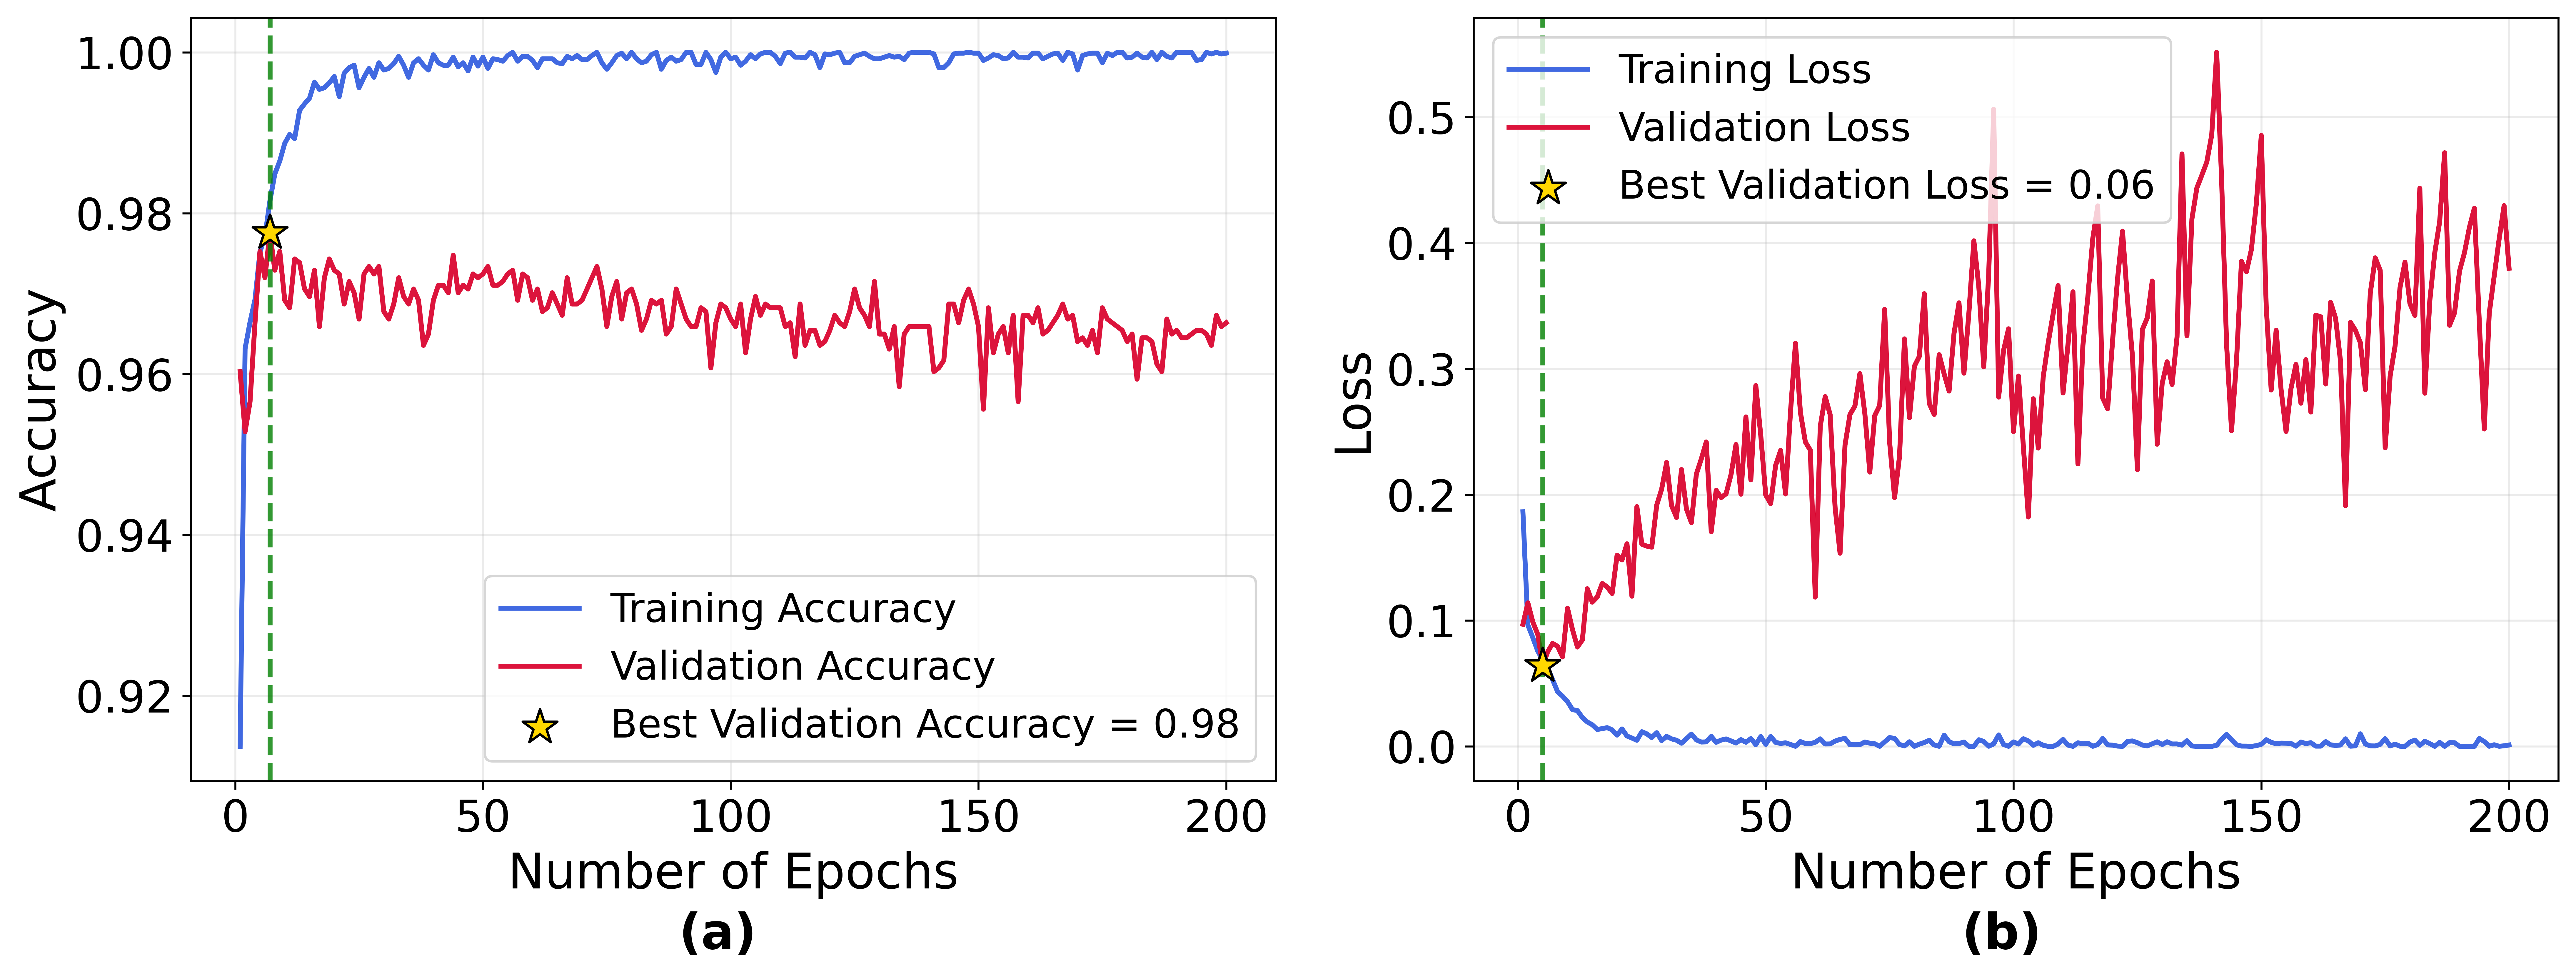

In [18]:
# ============================================================
# Font Settings
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# ============================================================
# Identify Best Epochs
# ============================================================

if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

best_acc_idx = df["val_accuracy"].idxmax()
best_acc_epoch = int(df.loc[best_acc_idx, "epoch"])
best_acc = float(df.loc[best_acc_idx, "val_accuracy"])

best_loss_idx = df["val_loss"].idxmin()
best_loss_epoch = int(df.loc[best_loss_idx, "epoch"])
best_loss = float(df.loc[best_loss_idx, "val_loss"])

# ============================================================
# Combined Learning Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# ============================================================
# Accuracy Plot
# ============================================================
ax1.plot(df["epoch"], df["accuracy"], linewidth=2,
         color="royalblue", label="Training Accuracy")

ax1.plot(df["epoch"], df["val_accuracy"], linewidth=2,
         color="crimson", label="Validation Accuracy")

ax1.axvline(best_acc_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax1.scatter(best_acc_epoch, best_acc,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Accuracy = {best_acc:.2f}")

ax1.set_xlabel("Number of Epochs")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True)

# Accuracy plot ticks
for tick, label in zip(ax1.get_xticks(), ax1.get_xticklabels()):
    if int(tick) == best_acc_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Loss Plot
# ============================================================
ax2.plot(df["epoch"], df["loss"], linewidth=2,
         color="royalblue", label="Training Loss")

ax2.plot(df["epoch"], df["val_loss"], linewidth=2,
         color="crimson", label="Validation Loss")

ax2.axvline(best_loss_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax2.scatter(best_loss_epoch, best_loss,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Loss = {best_loss:.2f}")

ax2.set_xlabel("Number of Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

# Loss plot ticks
for tick, label in zip(ax2.get_xticks(), ax2.get_xticklabels()):
    if int(tick) == best_loss_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Panel Labels
# ============================================================
ax1.text(0.45, -0.22, "(a)", transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

ax2.text(0.45, -0.22, "(b)", transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ============================================================
# Final layout
# ============================================================
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"),
            dpi=600, bbox_inches="tight")

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.pdf"),
            bbox_inches="tight")

plt.show()

### Classification Report


Evaluation Results: Train
Accuracy  : 1.000000
Precision : 1.000000
Recall    : 1.000000
F1-score  : 1.000000
ROC AUC   : 1.000000
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   1.000000  1.000000  1.000000      5000
         1.0   1.000000  1.000000  1.000000      4989

    accuracy                       1.000000      9989
   macro avg   1.000000  1.000000  1.000000      9989
weighted avg   1.000000  1.000000  1.000000      9989



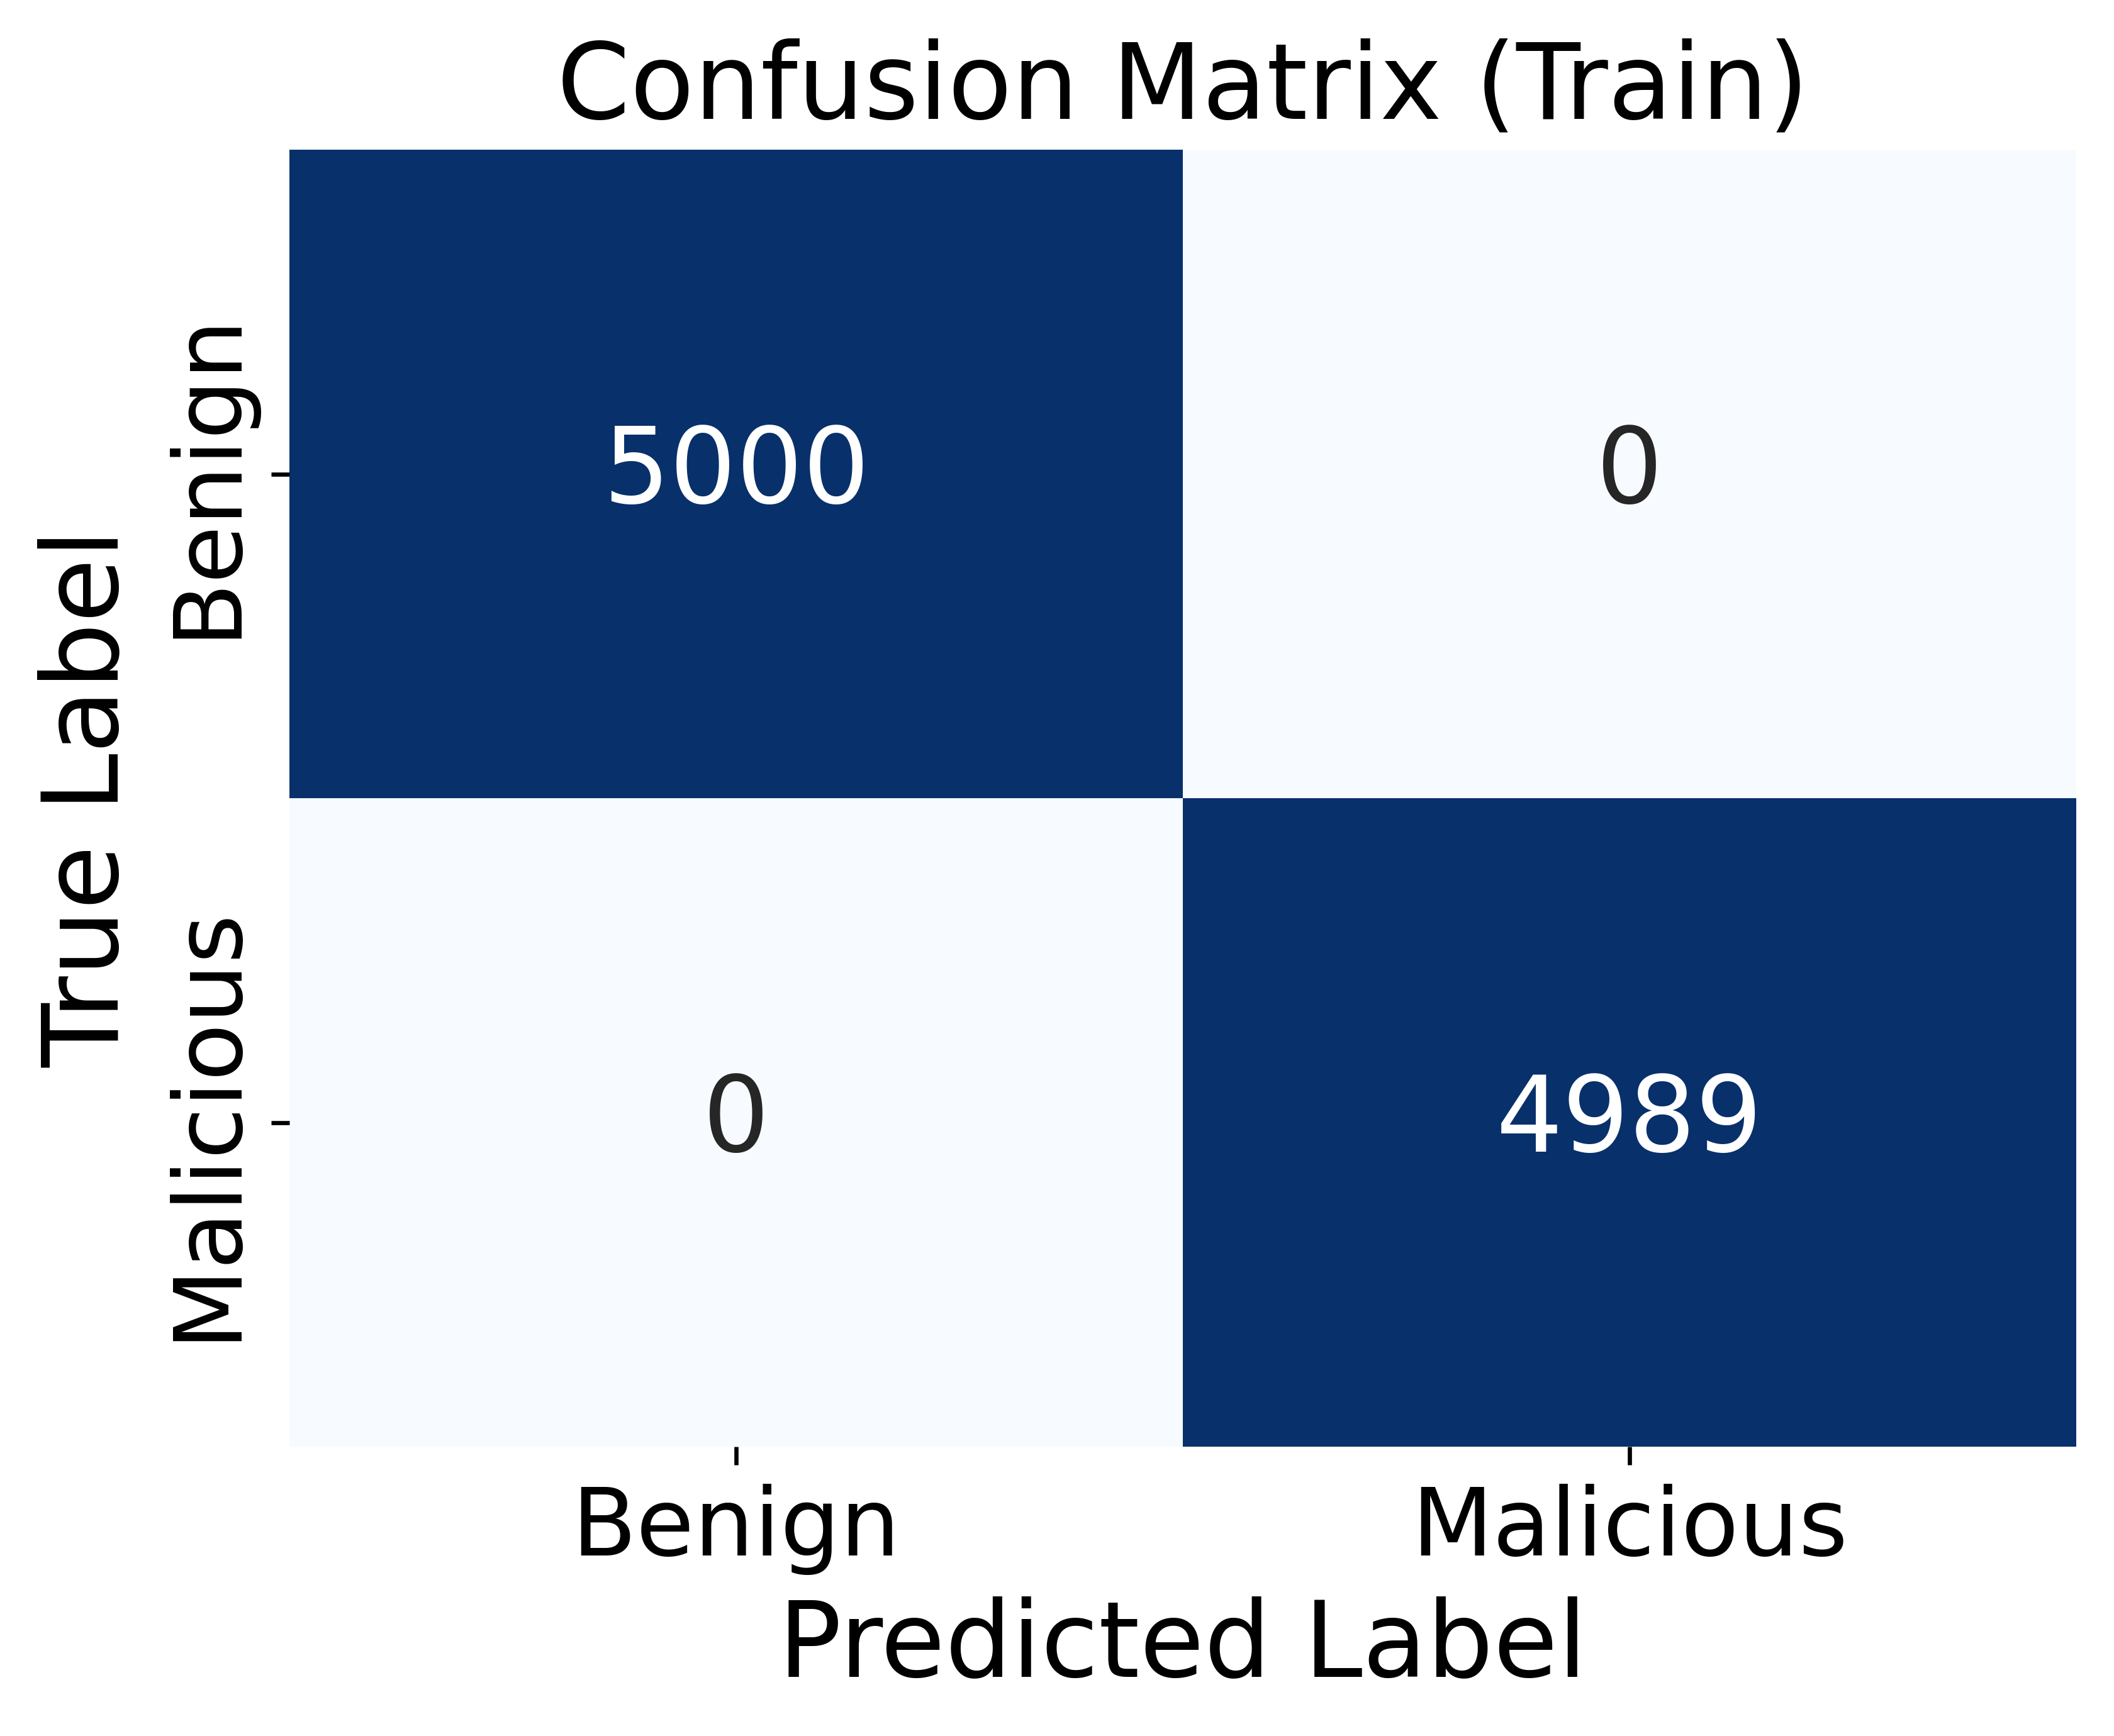

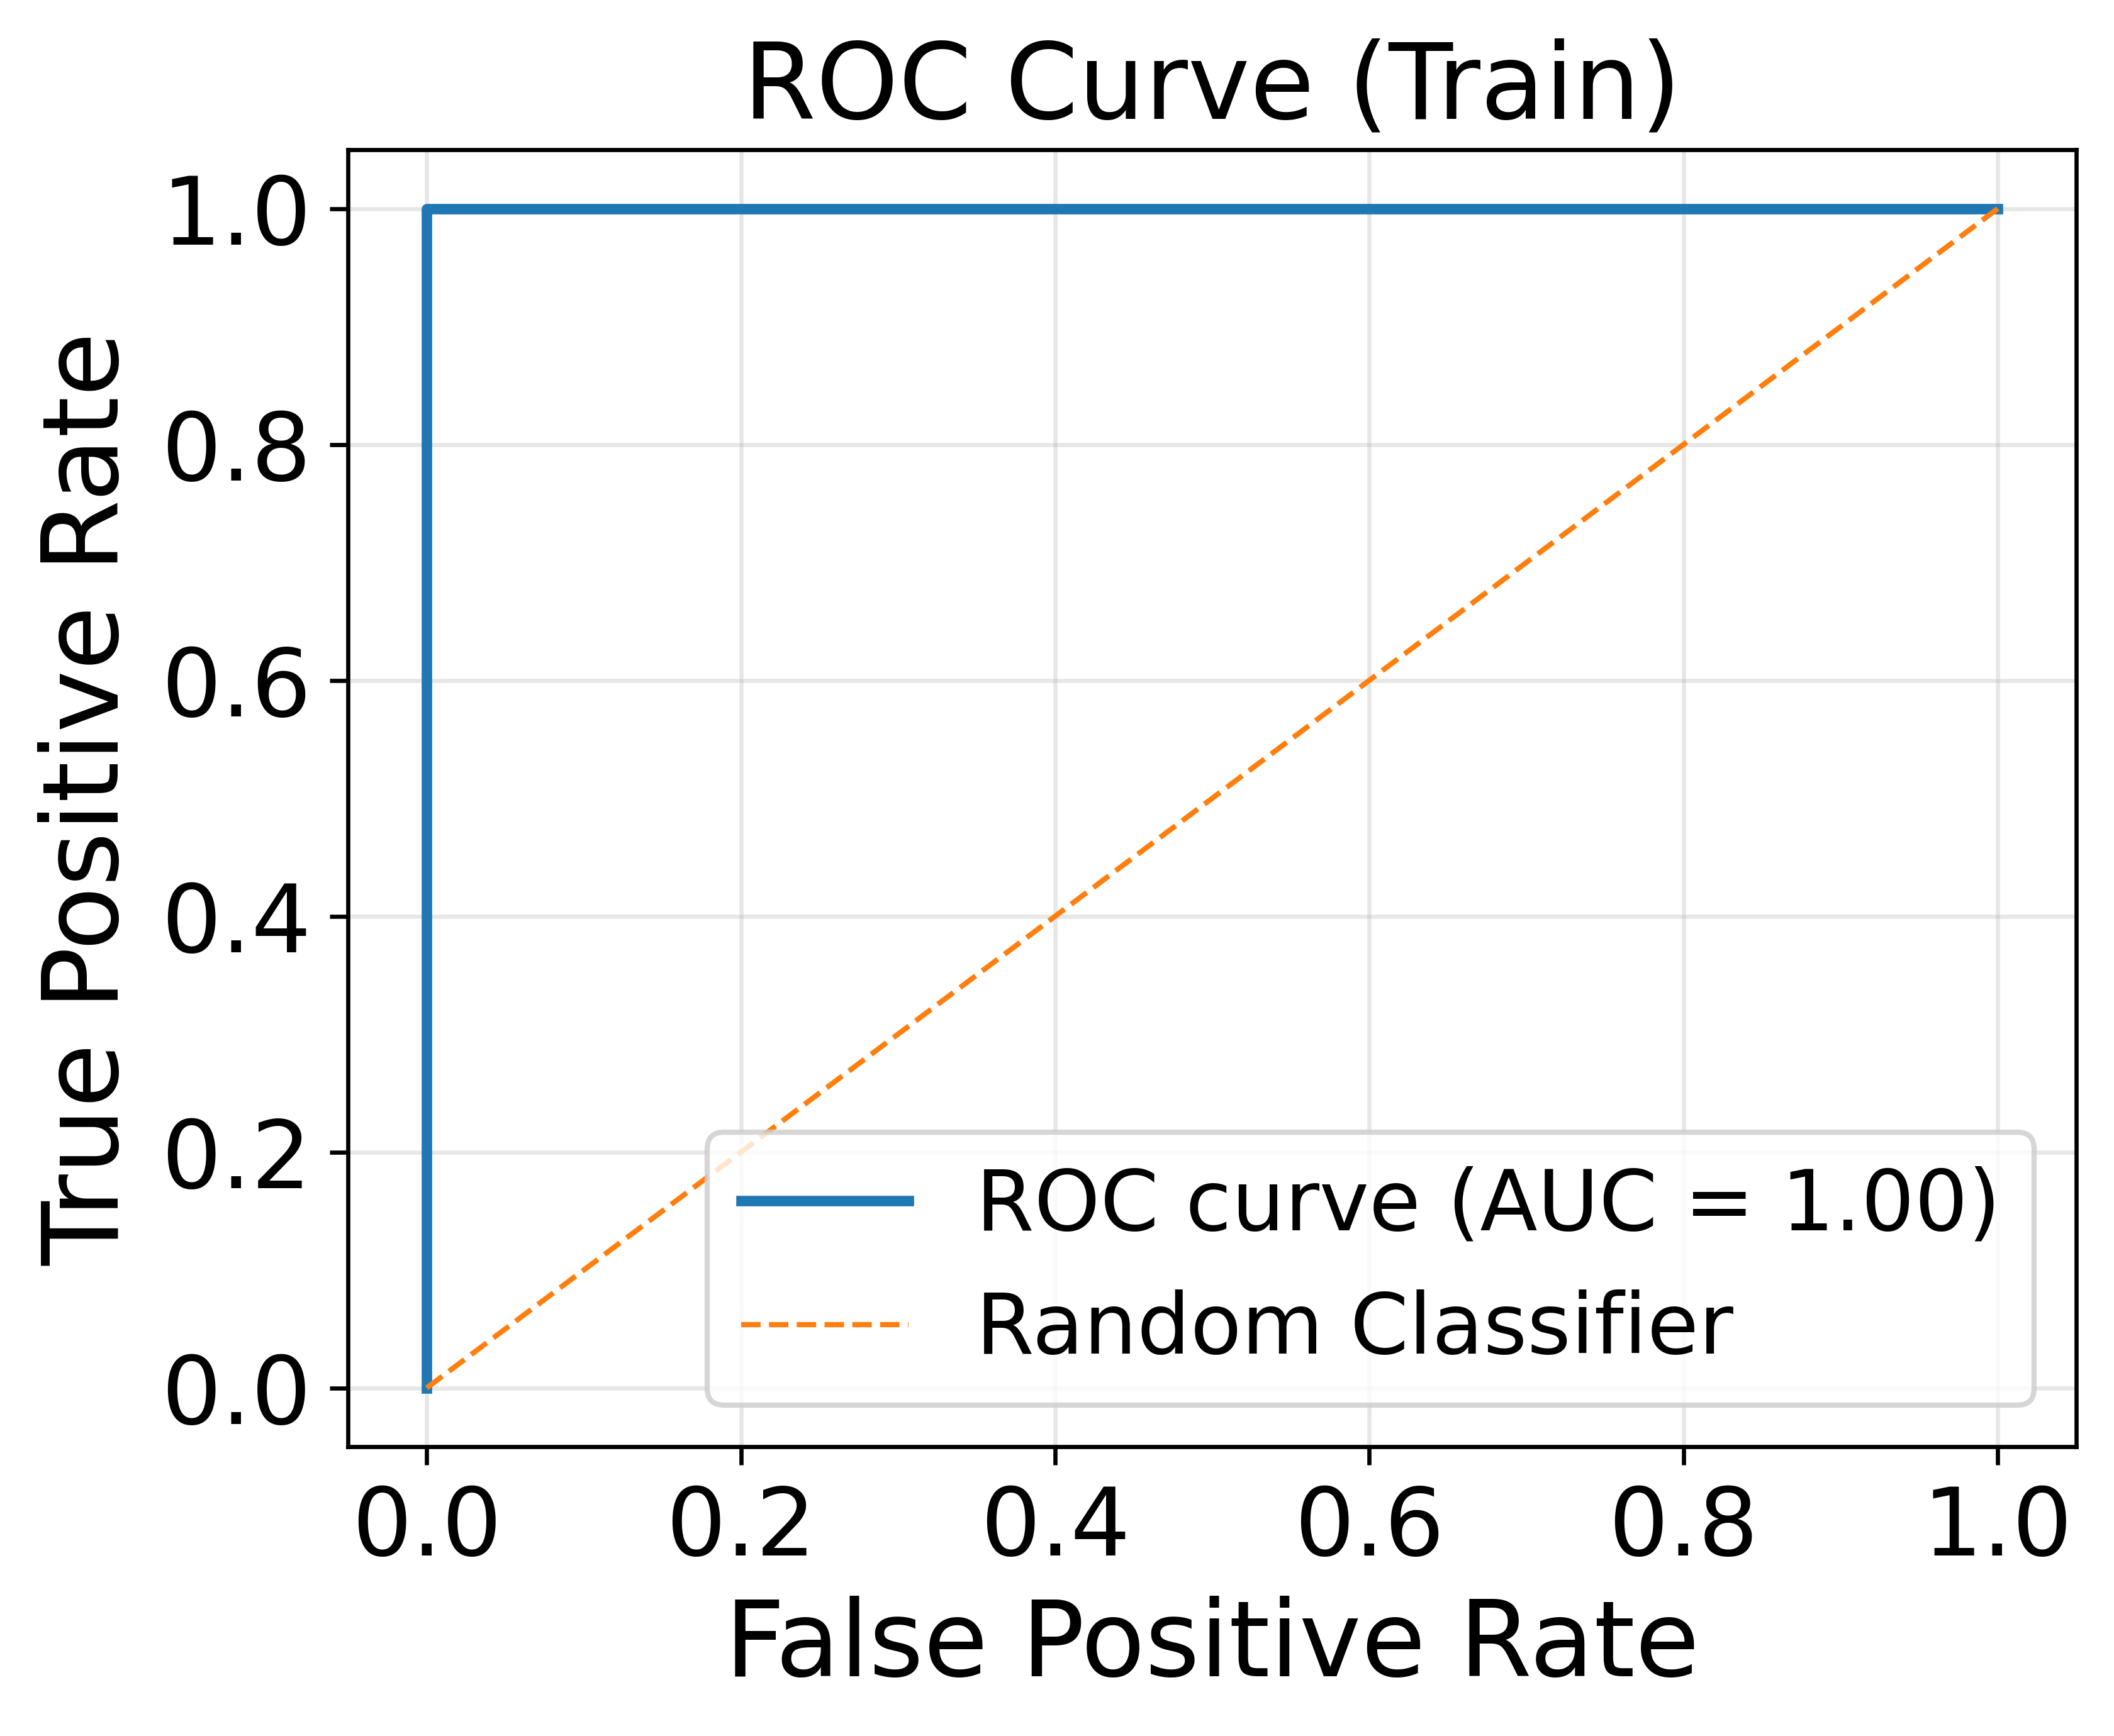


Evaluation Results: Validation
Accuracy  : 0.966371
Precision : 0.979788
Recall    : 0.952292
F1-score  : 0.965844
ROC AUC   : 0.983669
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.953721  0.980410  0.966881      1072
         1.0   0.979788  0.952292  0.965844      1069

    accuracy                       0.966371      2141
   macro avg   0.966754  0.966351  0.966363      2141
weighted avg   0.966736  0.966371  0.966364      2141



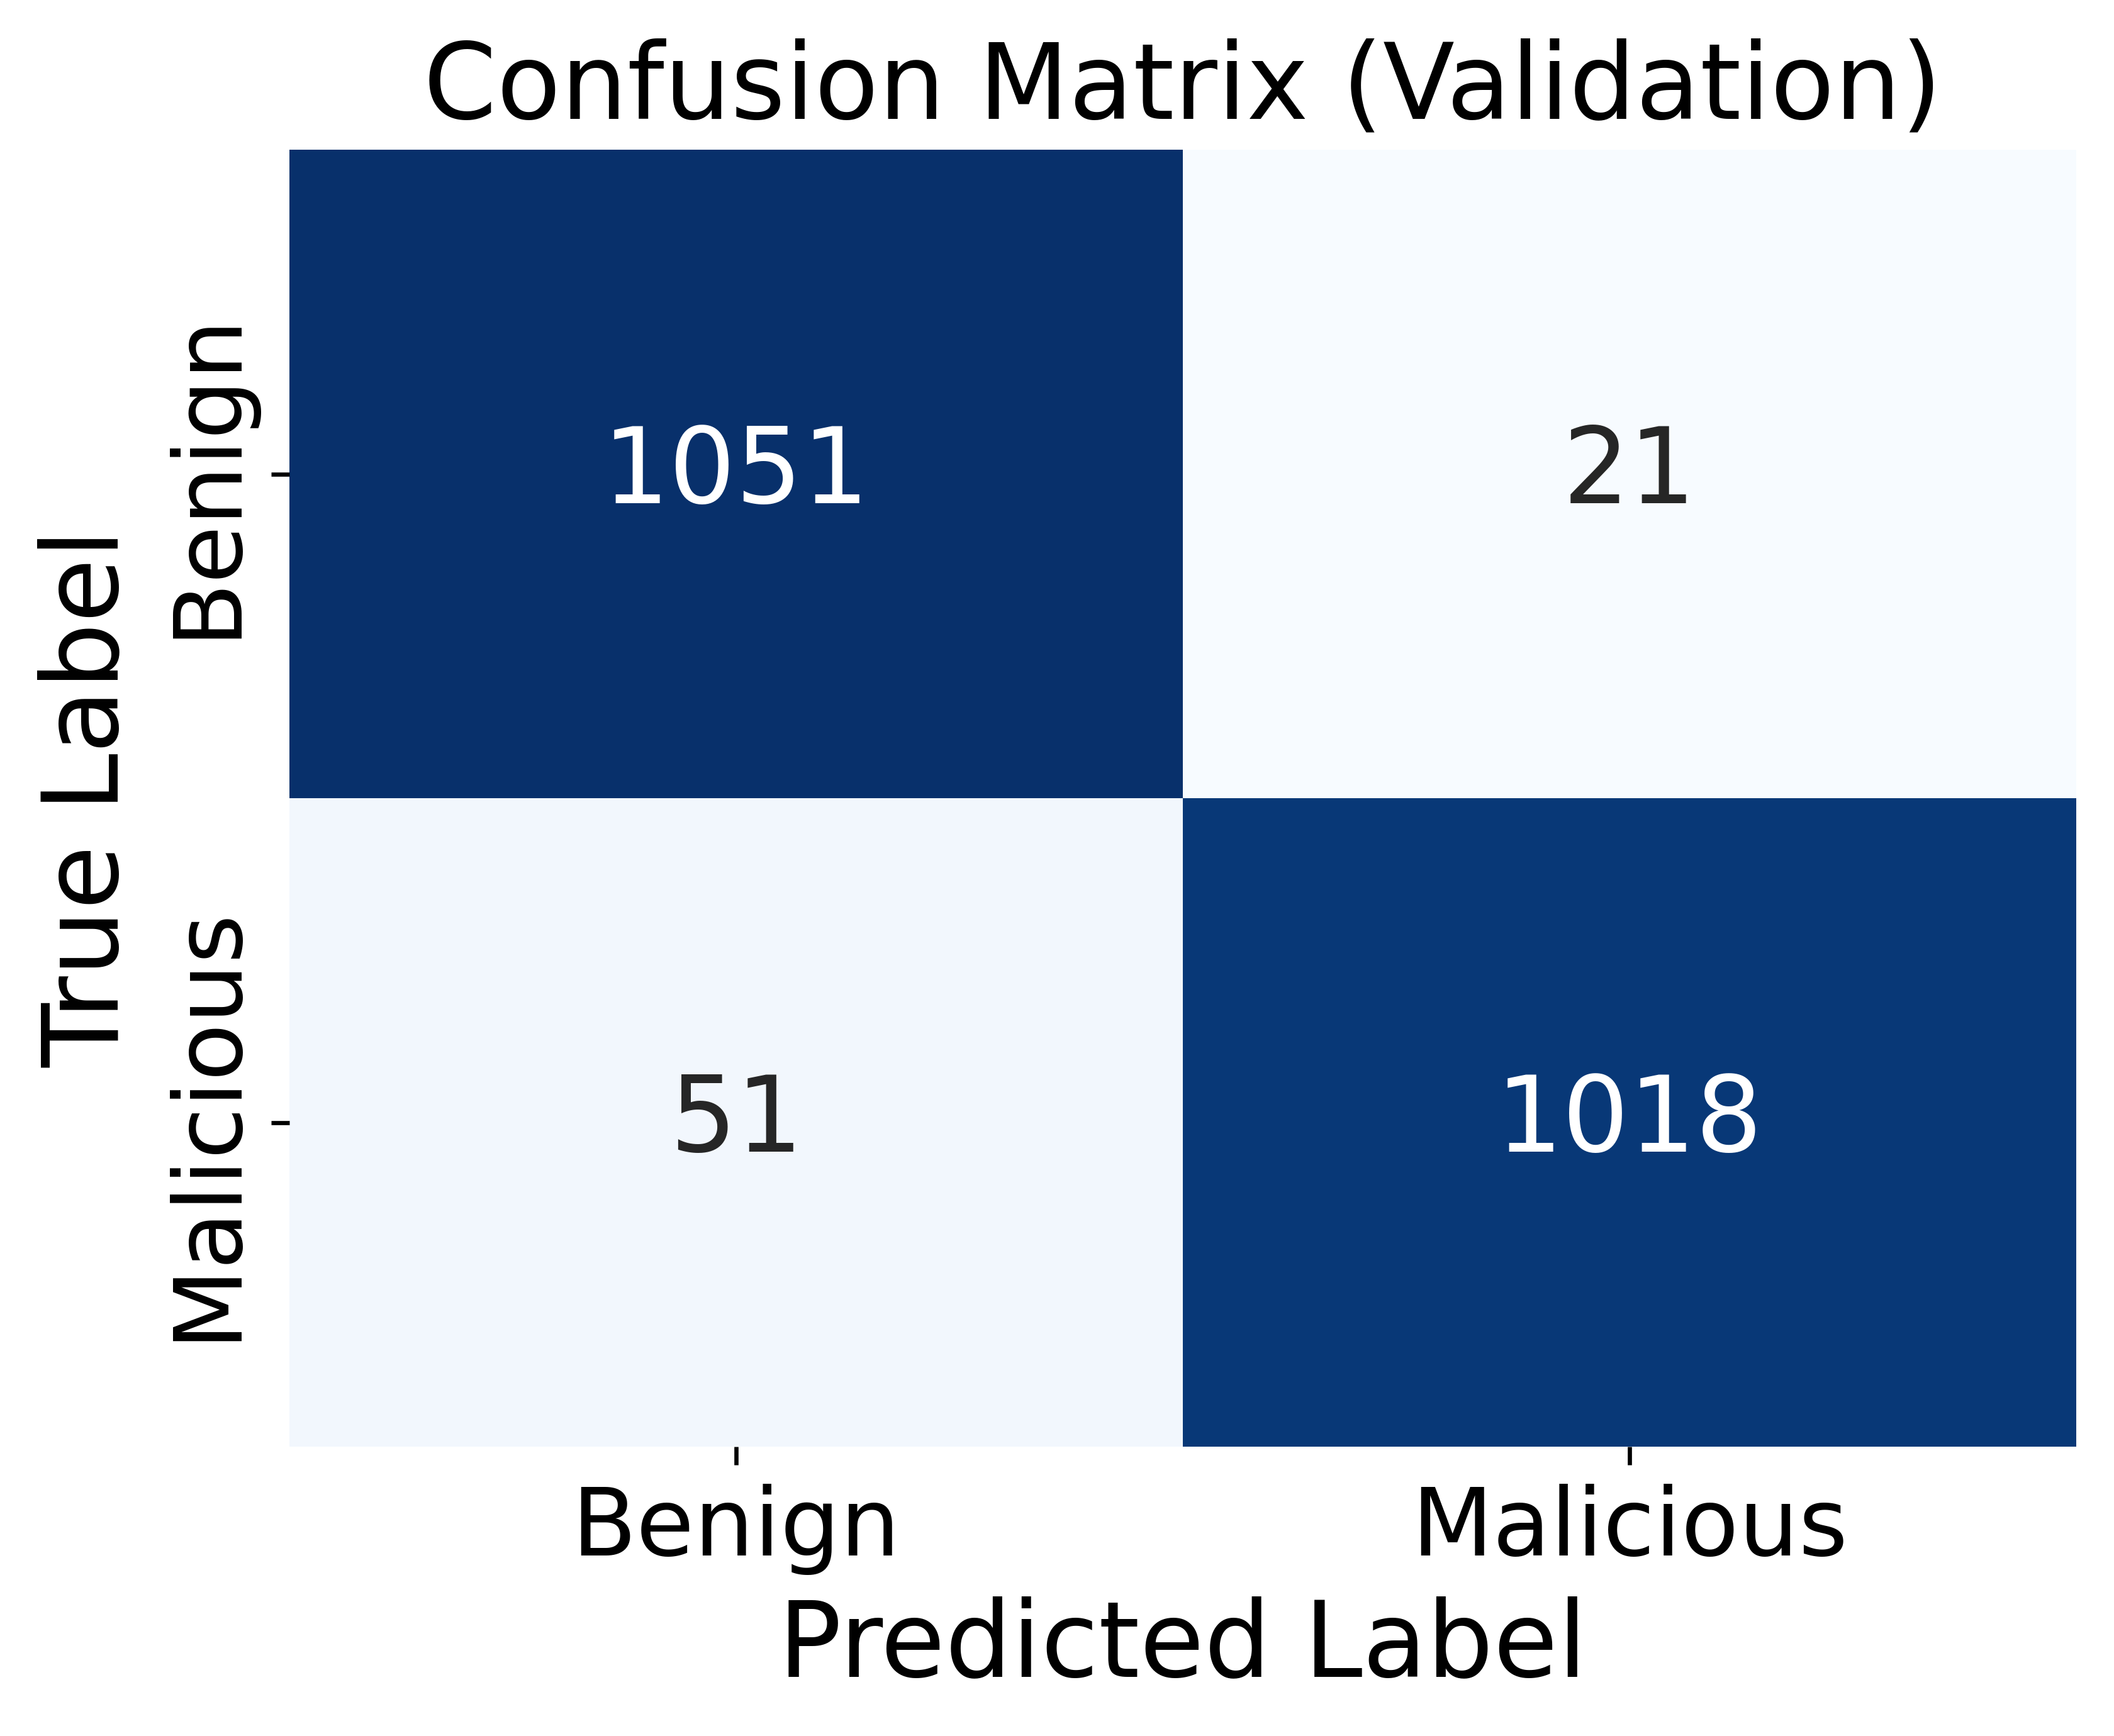

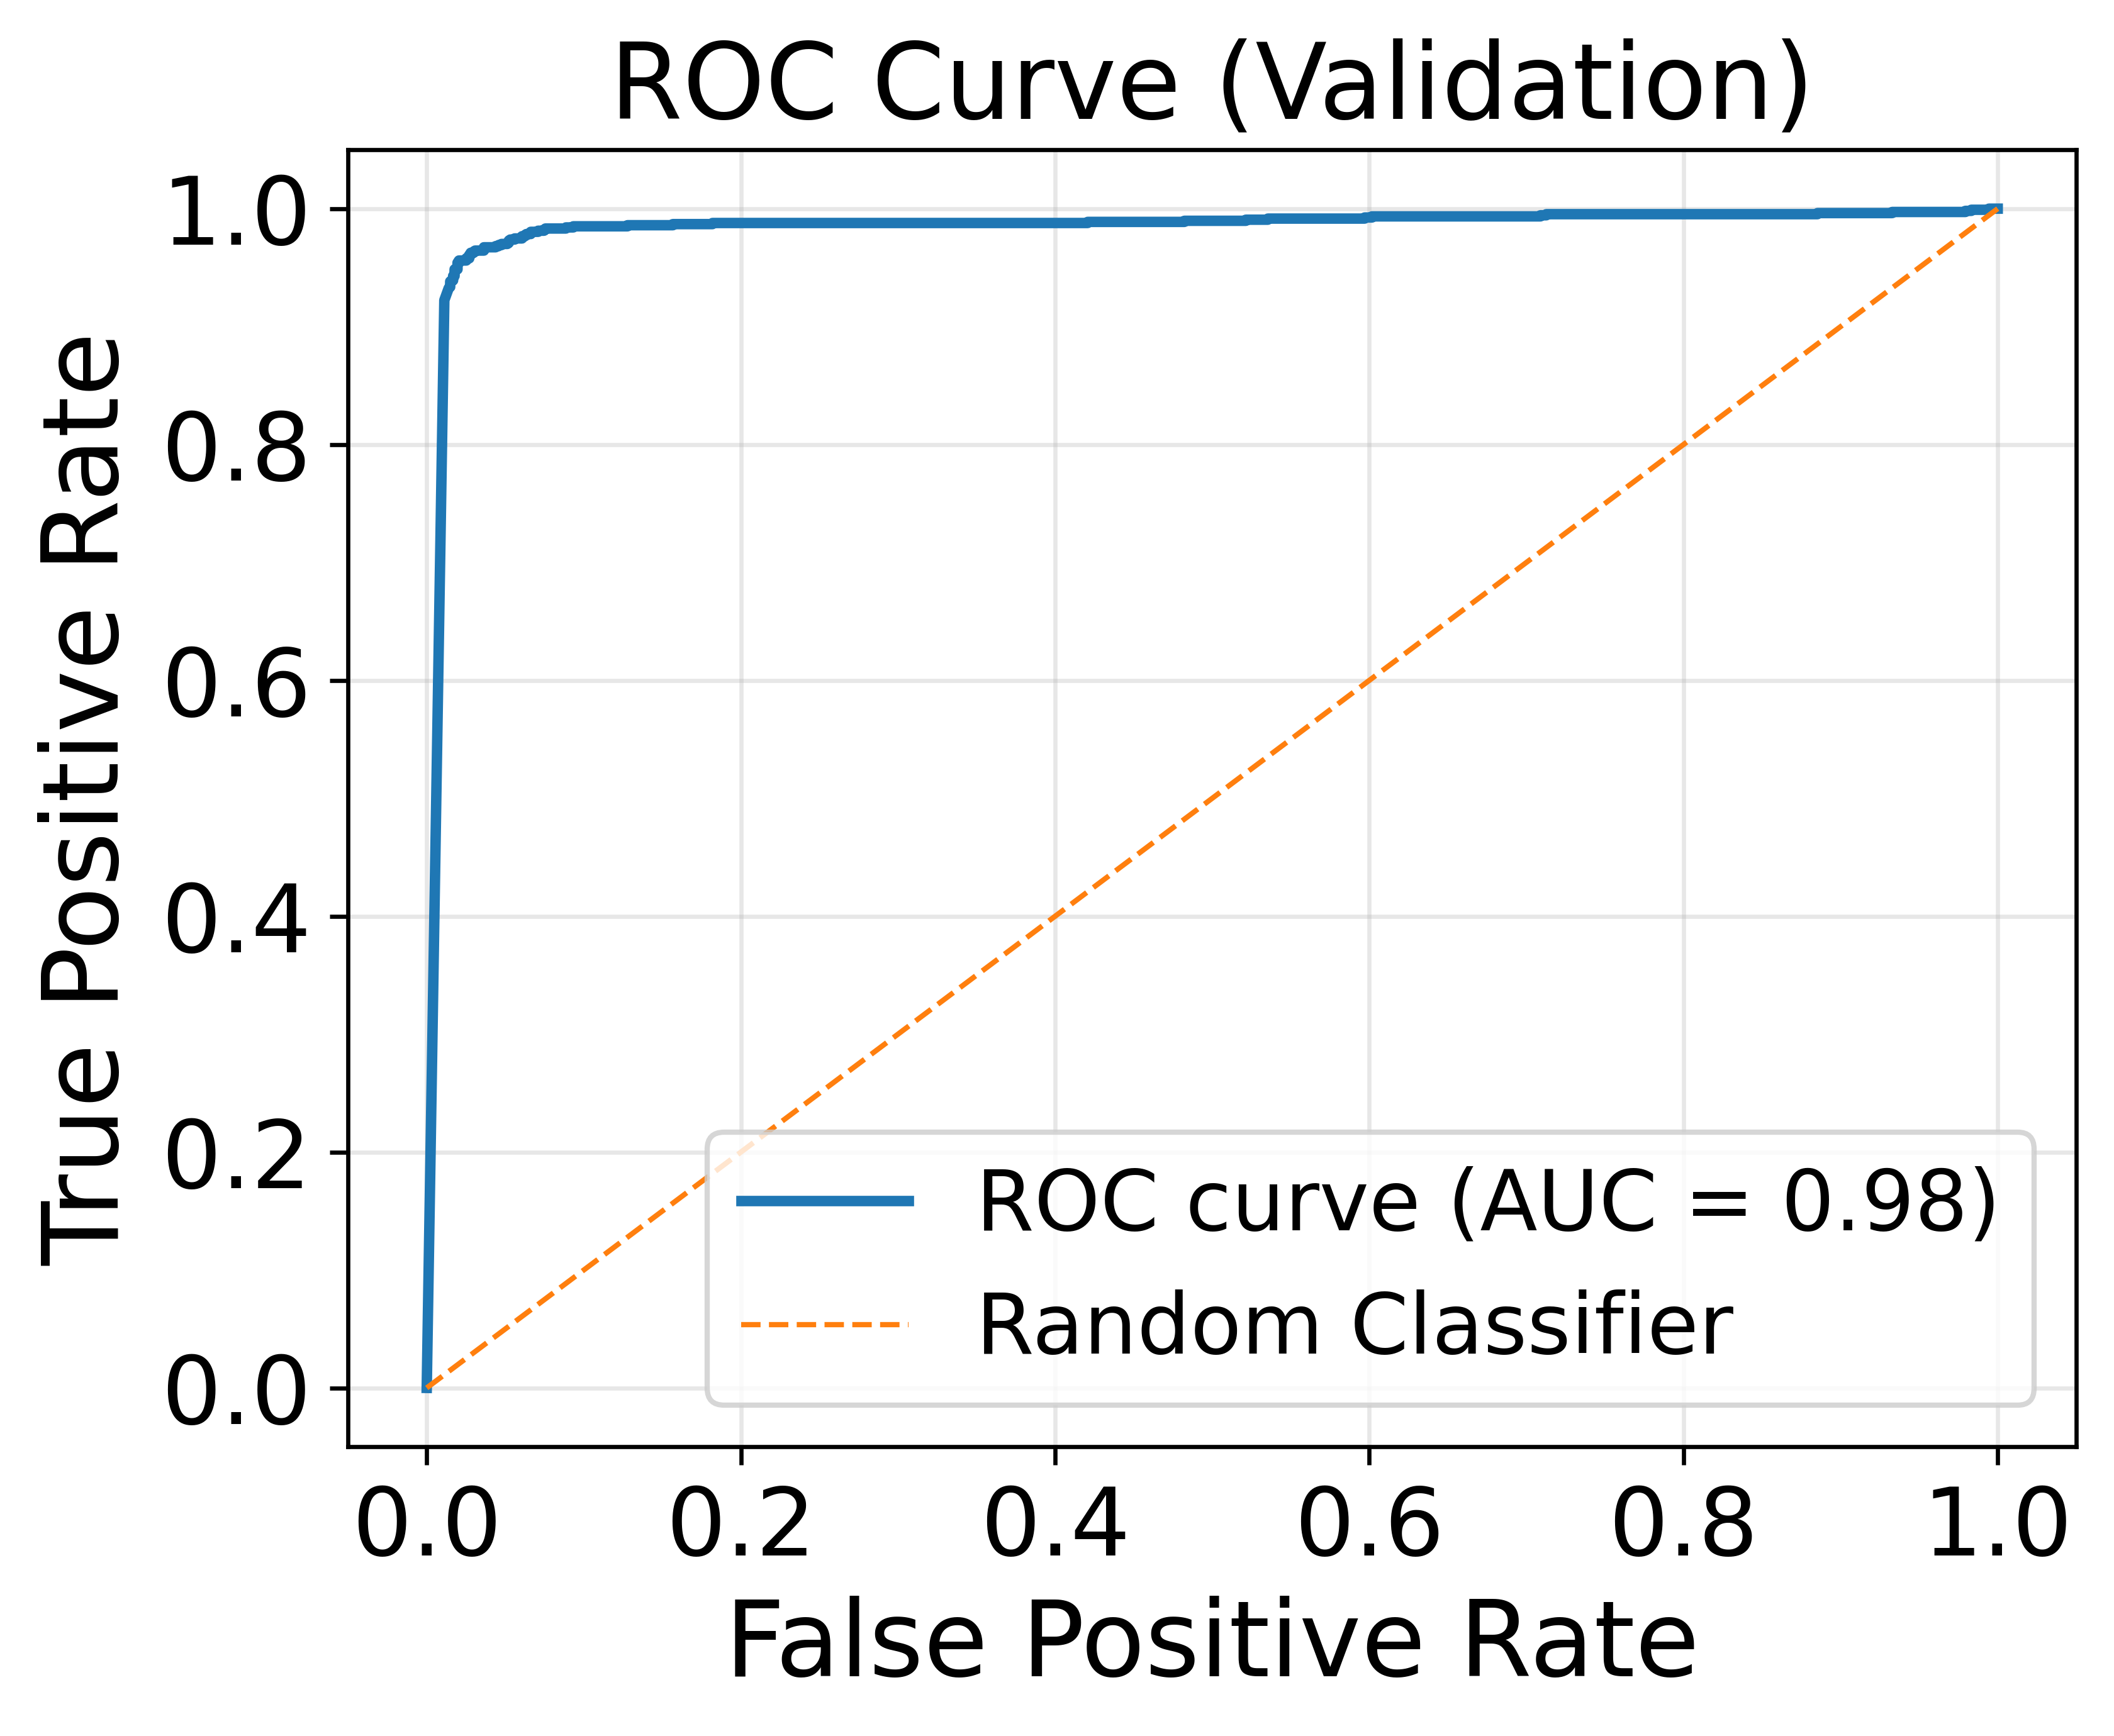


Evaluation Results: Test
Accuracy  : 0.972910
Precision : 0.976437
Recall    : 0.969130
F1-score  : 0.972770
ROC AUC   : 0.989346
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.969444  0.976679  0.973048      1072
         1.0   0.976437  0.969130  0.972770      1069

    accuracy                       0.972910      2141
   macro avg   0.972941  0.972905  0.972909      2141
weighted avg   0.972936  0.972910  0.972909      2141



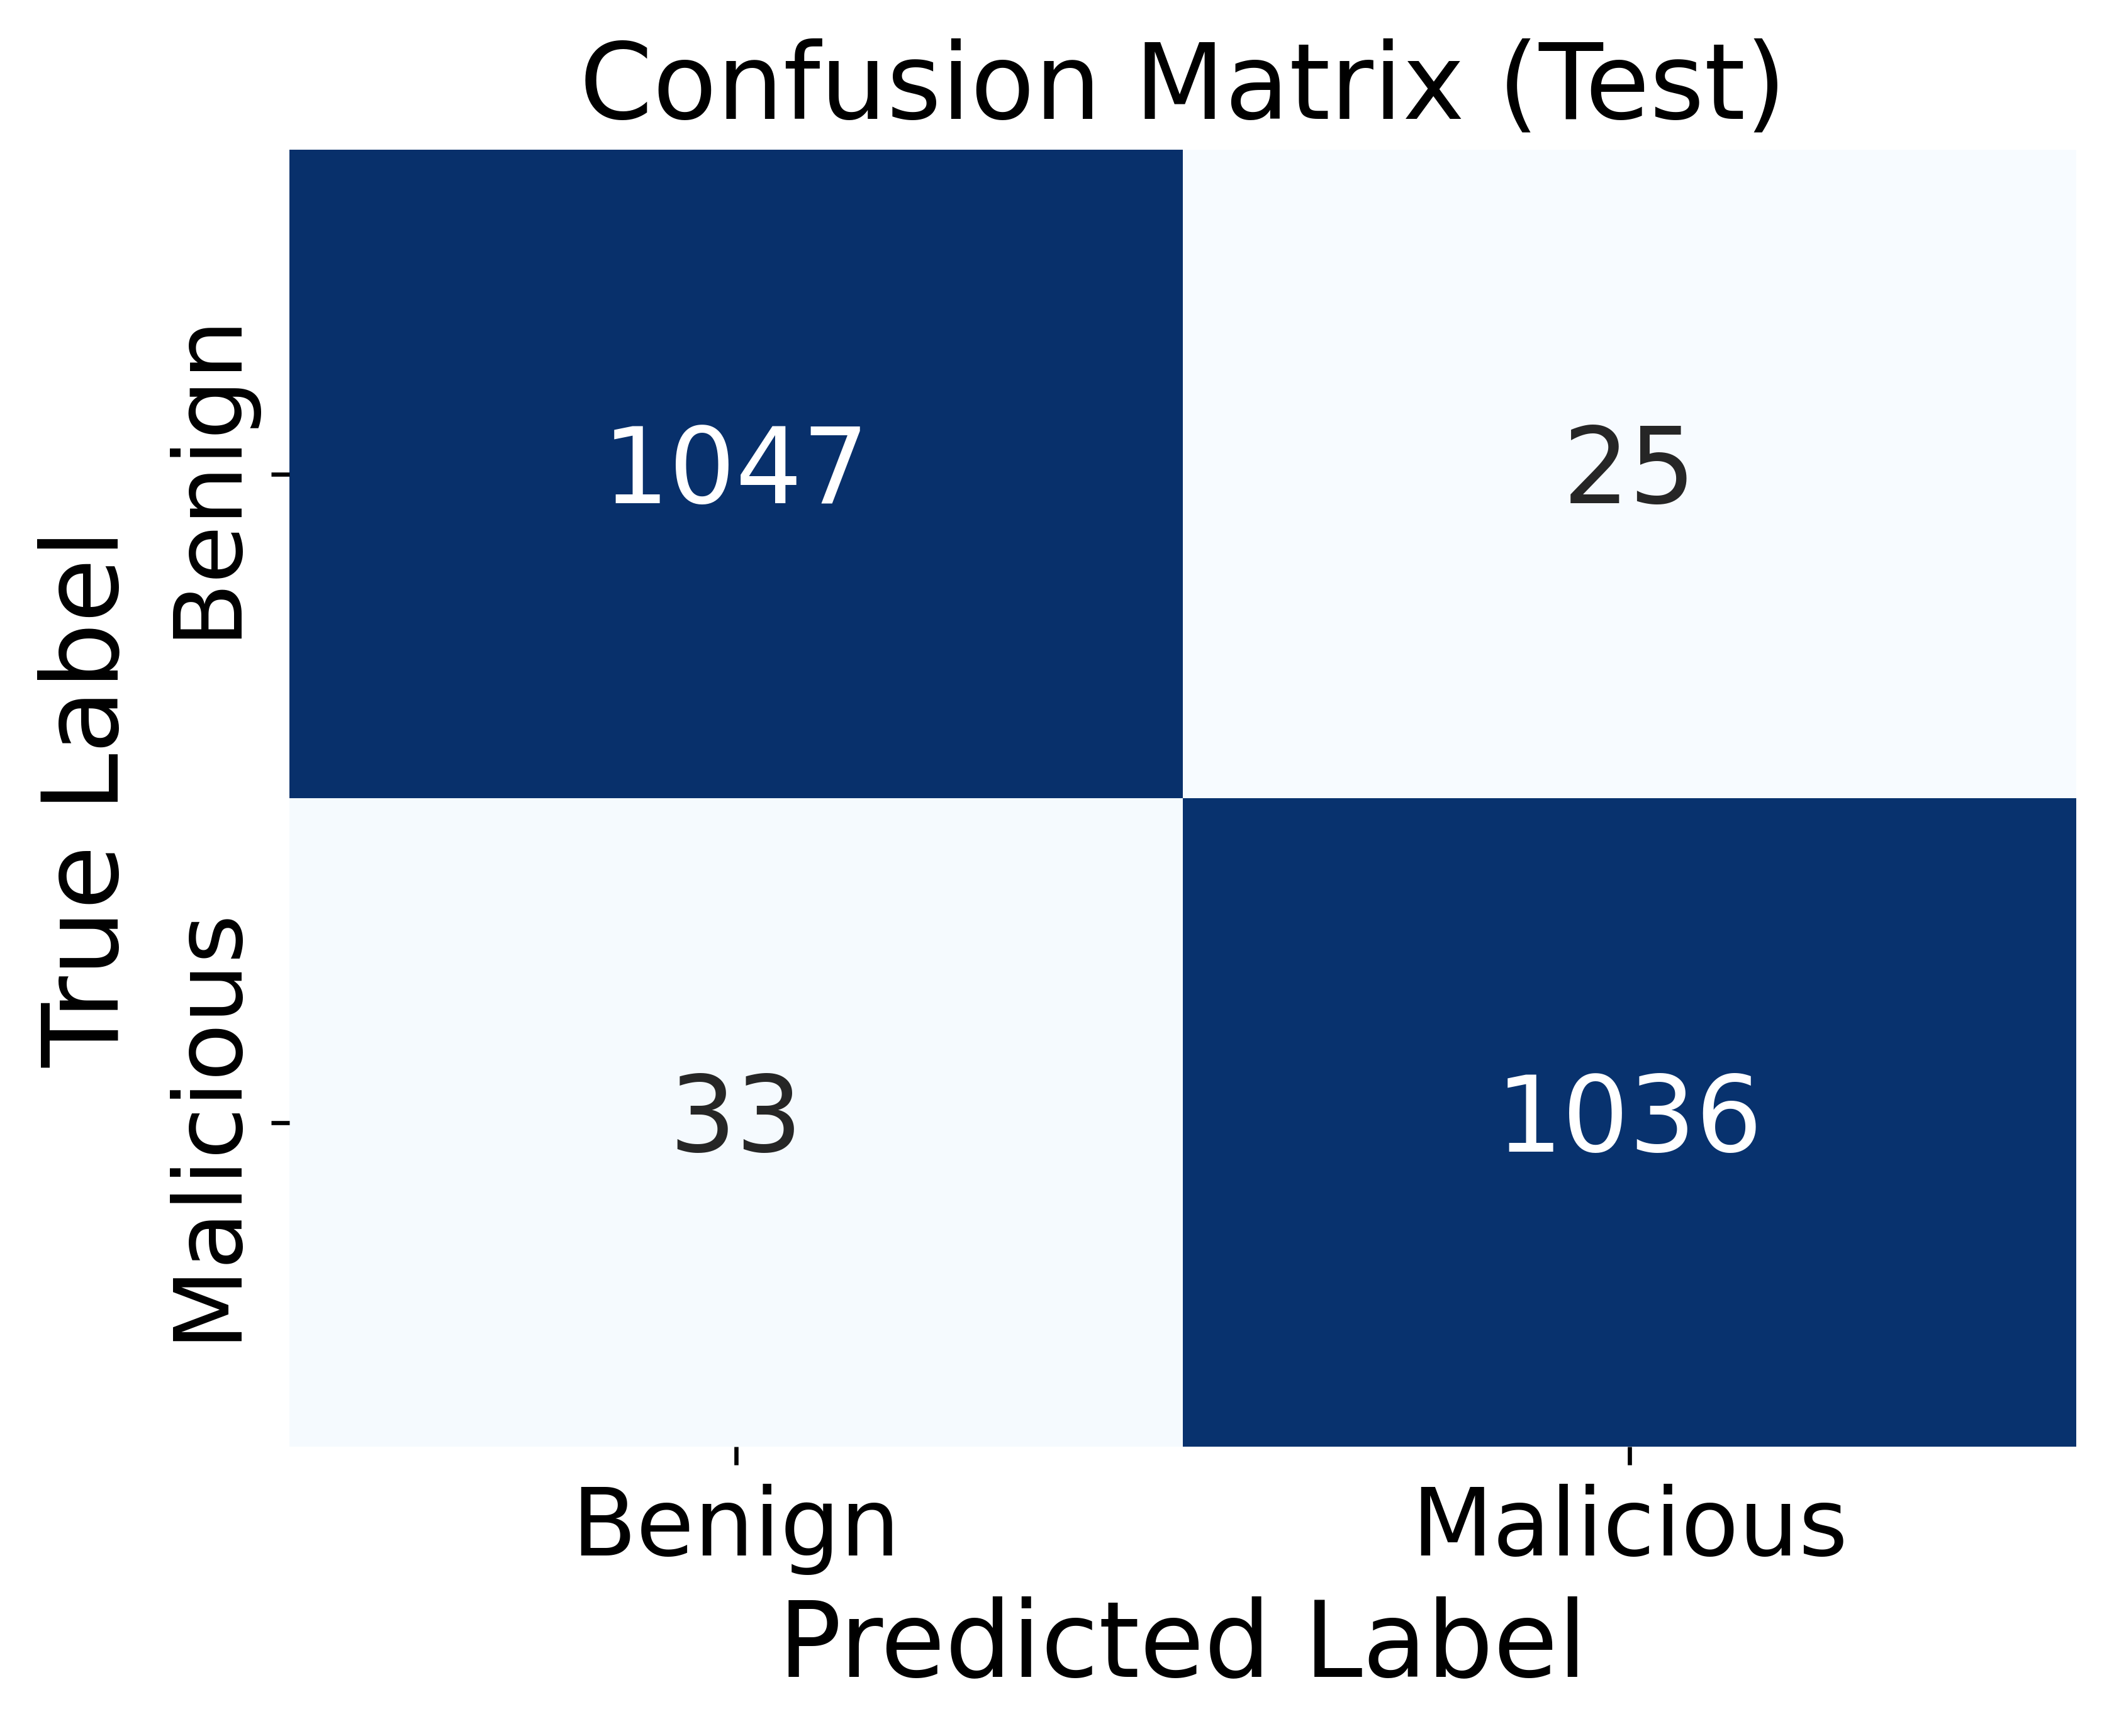

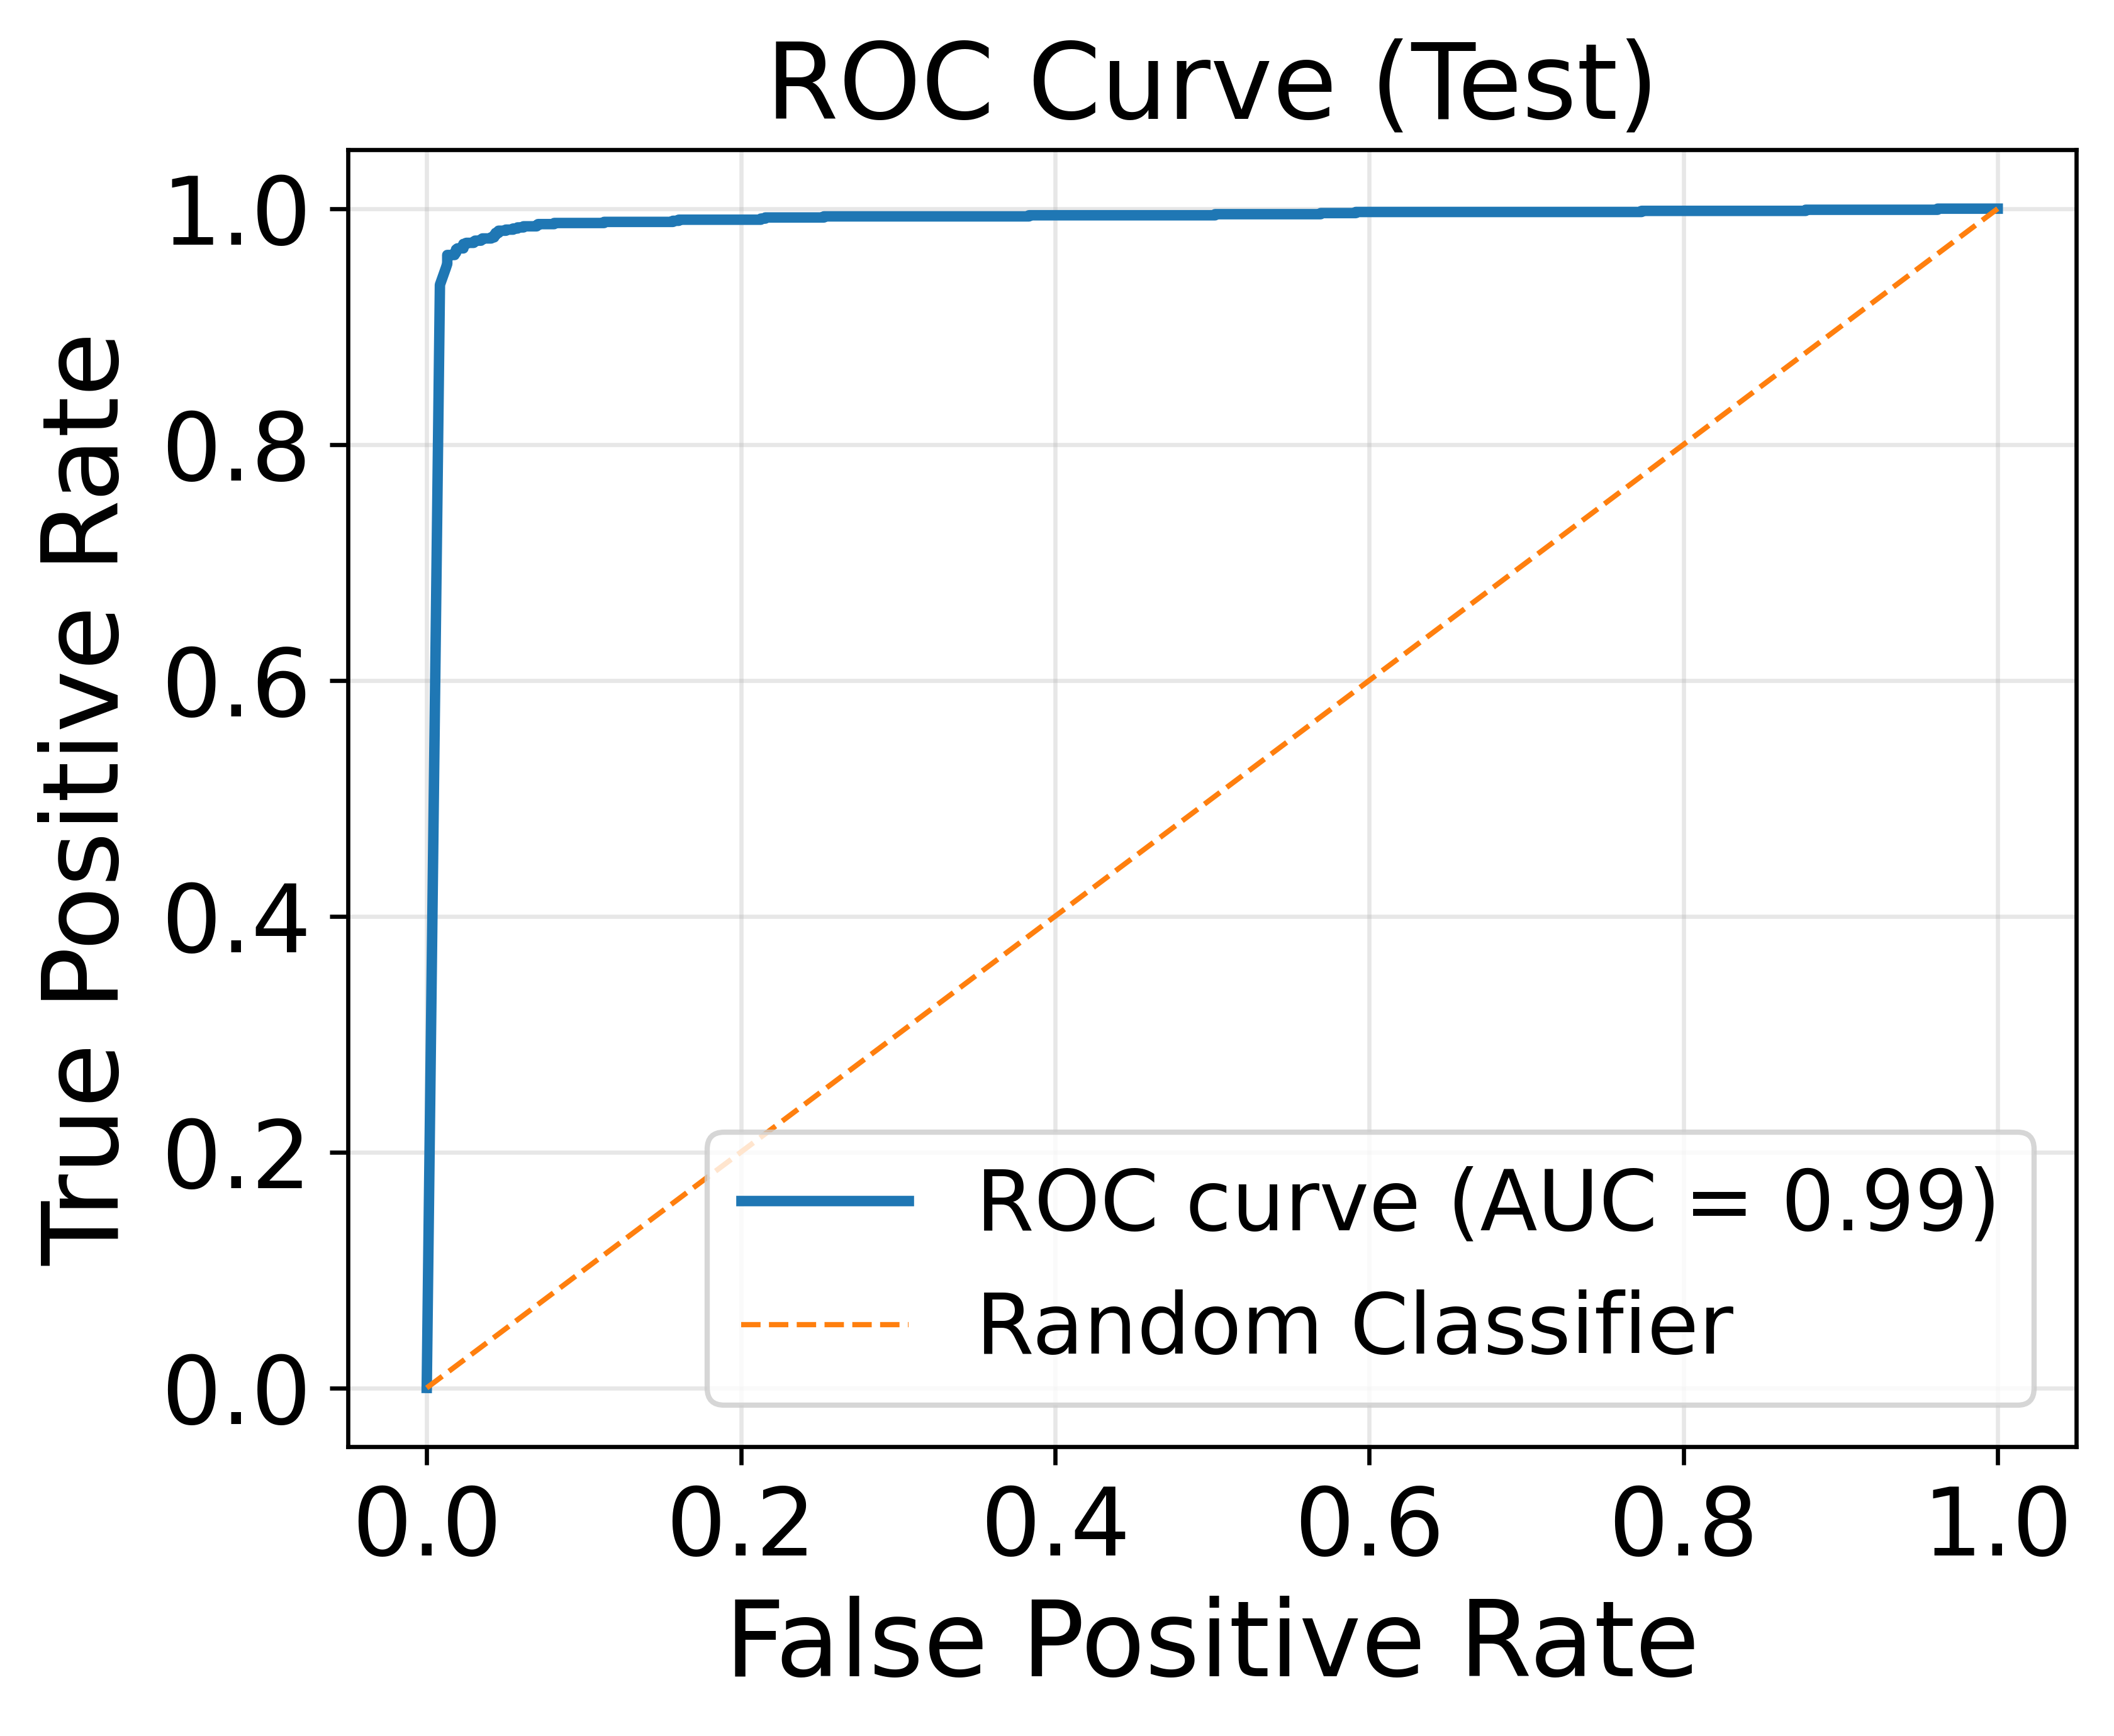

In [19]:
def evaluate_and_plot(model, encodings, y_true, dataset_name, output_dir=OUTPUT_DIR):
    """
    Evaluate the trained model on a given dataset and generate
    publication-quality confusion matrix and ROC curve figures.

    Parameters
    ----------
    model : keras.Model
        Trained classification model.
    encodings : dict or BatchEncoding
        Tokenized transformer inputs containing 'input_ids' and 'attention_mask'.
    y_true : array-like
        Ground-truth labels.
    dataset_name : str
        Name of the dataset split (e.g., 'Train', 'Validation', 'Test').
    output_dir : str, optional
        Directory where evaluation figures will be saved.

    Returns
    -------
    results : dict
        Dictionary containing predictions and evaluation metrics.
    """

    # --------------------------------------------------------
    # Prepare model inputs
    # --------------------------------------------------------
    inputs = [
        np.array(encodings["input_ids"]),
        np.array(encodings["attention_mask"])
    ]

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_prob = model.predict(inputs, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=6)

    # --------------------------------------------------------
    # Print evaluation summary
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"Evaluation Results: {dataset_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.6f}")
    print(f"Precision : {prec:.6f}")
    print(f"Recall    : {rec:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC AUC   : {roc_auc:.6f}")
    print("-" * 70)
    print("Classification Report:")
    print(report)

    # --------------------------------------------------------
    # Plot and save confusion matrix
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Malicious"],
        yticklabels=["Benign", "Malicious"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.tight_layout()

    cm_png = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.png")
    cm_pdf = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.pdf")
    plt.savefig(cm_png, dpi=600, bbox_inches="tight")
    plt.savefig(cm_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Plot and save ROC curve
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({dataset_name})")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_png = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.png")
    roc_pdf = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.pdf")
    plt.savefig(roc_png, dpi=600, bbox_inches="tight")
    plt.savefig(roc_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Return results for further analysis/reporting
    # --------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y_true),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix_png": cm_png,
        "confusion_matrix_pdf": cm_pdf,
        "roc_curve_png": roc_png,
        "roc_curve_pdf": roc_pdf
    }

    return results


# ============================================================
# Evaluate on Training, Validation, and Test Sets
# ============================================================

train_results = evaluate_and_plot(model, train_enc, y_train, "Train")
val_results   = evaluate_and_plot(model, val_enc, y_val, "Validation")
test_results  = evaluate_and_plot(model, test_enc, y_test, "Test")

### Save All Results

In [20]:
# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Dataset": train_results["dataset"],
        "Accuracy": train_results["accuracy"],
        "Precision": train_results["precision"],
        "Recall": train_results["recall"],
        "F1-score": train_results["f1_score"],
        "ROC AUC": train_results["roc_auc"]
    },
    {
        "Dataset": val_results["dataset"],
        "Accuracy": val_results["accuracy"],
        "Precision": val_results["precision"],
        "Recall": val_results["recall"],
        "F1-score": val_results["f1_score"],
        "ROC AUC": val_results["roc_auc"]
    },
    {
        "Dataset": test_results["dataset"],
        "Accuracy": test_results["accuracy"],
        "Precision": test_results["precision"],
        "Recall": test_results["recall"],
        "F1-score": test_results["f1_score"],
        "ROC AUC": test_results["roc_auc"]
    }
])

# ------------------------------------------------------------
# Define save paths
# ------------------------------------------------------------
csv_path  = os.path.join(OUTPUT_DIR, "evaluation_summary.csv")
xlsx_path = os.path.join(OUTPUT_DIR, "evaluation_summary.xlsx")

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------
summary_df.to_csv(csv_path, index=False)
summary_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------
print("=" * 60)
print("Evaluation summary saved successfully:")
print(f"CSV  : {csv_path}")
print(f"Excel: {xlsx_path}")
print("=" * 60)

# Display table
summary_df

Evaluation summary saved successfully:
CSV  : Evaluation_Outputs_Combined_ANOVA_Attention_BERT/evaluation_summary.csv
Excel: Evaluation_Outputs_Combined_ANOVA_Attention_BERT/evaluation_summary.xlsx


,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Train,1.000000,1.000000,1.000000,1.000000,1.000000
1,Validation,0.966371,0.979788,0.952292,0.965844,0.983669
2,Test,0.972910,0.976437,0.969130,0.972770,0.989346


### Clear Final Backend Session

In [21]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()